# K-Means Clustering — Mall Customers
Clusters customers by **Annual Income** and **Spending Score**.

In [1]:
# ── All imports & global settings in one place ──────────────────────────────
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Fix Windows MKL memory-leak warning
os.environ["OMP_NUM_THREADS"] = "1"

# Reproducibility
RANDOM_STATE = 42

## 1 · Load & inspect data

In [2]:
dataset = pd.read_csv('Mall_Customers.csv')

print(f"Shape : {dataset.shape}")
print(f"\nColumn dtypes:\n{dataset.dtypes}")
print(f"\nMissing values:\n{dataset.isnull().sum()}")
dataset.head()

Shape : (200, 5)

Column dtypes:
CustomerID                 int64
Genre                     object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

Missing values:
CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 2 · Feature extraction
Use named columns (more robust than positional indexing).

In [3]:
FEATURE_COLS = ['Annual Income (k$)', 'Spending Score (1-100)']
X = dataset[FEATURE_COLS].values
print(f"Feature matrix shape: {X.shape}")

Feature matrix shape: (200, 2)


## 3 · Determine optimal *k*
Use the **Elbow method** (WCSS) **and** the **Silhouette score** together.

C:\Users\Maheshwaran\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Maheshwaran\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Maheshwaran\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Maheshwaran\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have

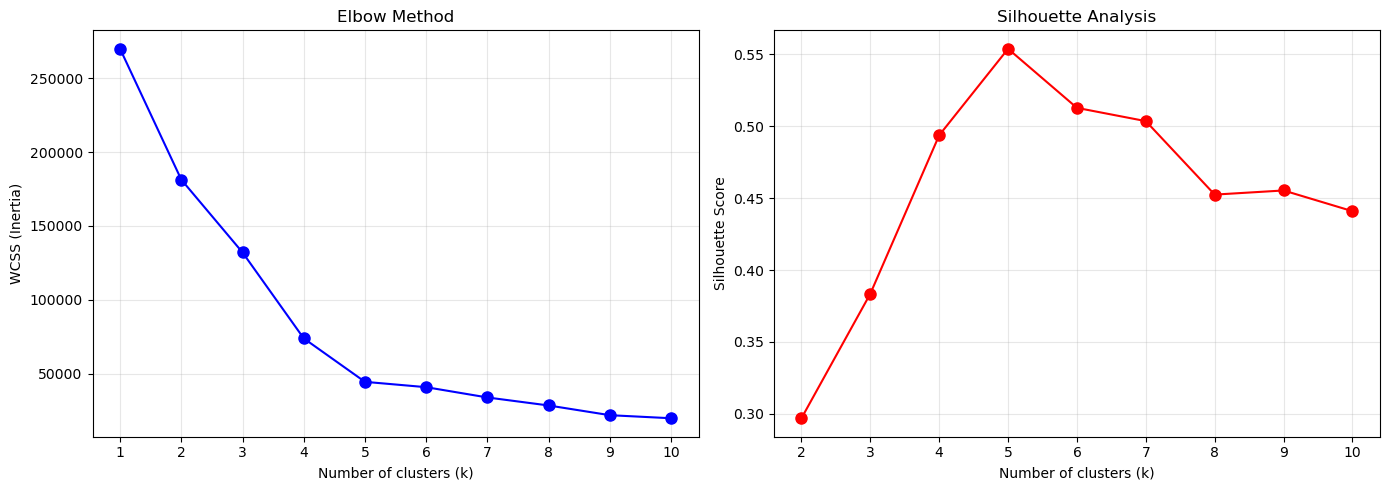

Best k by Silhouette: 5  (score = 0.5539)
WCSS values: [269981.3, 181363.6, 132087.7, 73880.6, 44448.5, 40825.2, 33859.4, 28437.5, 21862.1, 19787.7]


In [4]:
K_RANGE = range(1, 11)
wcss = []
silhouette_scores = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, init='k-means++', n_init='auto', random_state=RANDOM_STATE)
    labels = km.fit_predict(X)
    wcss.append(km.inertia_)
    # Silhouette requires at least 2 clusters
    if k >= 2:
        silhouette_scores.append(silhouette_score(X, labels))

# ── Plots ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow curve
axes[0].plot(list(K_RANGE), wcss, 'bo-', markersize=8)
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('WCSS (Inertia)')
axes[0].set_title('Elbow Method')
axes[0].set_xticks(list(K_RANGE))
axes[0].grid(True, alpha=0.3)

# Silhouette scores (k = 2..10)
k_sil = list(range(2, 11))
axes[1].plot(k_sil, silhouette_scores, 'ro-', markersize=8)
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Analysis')
axes[1].set_xticks(k_sil)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_k_sil = k_sil[silhouette_scores.index(max(silhouette_scores))]
print(f"Best k by Silhouette: {best_k_sil}  (score = {max(silhouette_scores):.4f})")
print(f"WCSS values: {[round(w, 1) for w in wcss]}")

## 4 · Fit final K-Means model (k = 5)

In [5]:
OPTIMAL_K = 5

kmeans = KMeans(
    n_clusters=OPTIMAL_K,
    init='k-means++',
    n_init='auto',
    random_state=RANDOM_STATE
)
y_kmeans = kmeans.fit_predict(X)

print(f"Inertia (WCSS) : {kmeans.inertia_:.2f}")
print(f"Iterations     : {kmeans.n_iter_}")
print("\nCluster centroids:")
centroids = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=FEATURE_COLS,
    index=[f'Cluster {i}' for i in range(OPTIMAL_K)]
).round(2)
print(centroids)

Inertia (WCSS) : 44448.46
Iterations     : 3

Cluster centroids:
           Annual Income (k$)  Spending Score (1-100)
Cluster 0               55.30                   49.52
Cluster 1               88.20                   17.11
Cluster 2               26.30                   20.91
Cluster 3               25.73                   79.36
Cluster 4               86.54                   82.13


C:\Users\Maheshwaran\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


## 5 · Attach cluster labels & summarise

In [6]:
# .copy() avoids SettingWithCopyWarning and protects the original dataframe
supervised = dataset.copy()
supervised['Cluster'] = y_kmeans

print("Cluster sizes:")
print(supervised['Cluster'].value_counts().sort_index())

print("\nCluster means (feature columns):")
supervised.groupby('Cluster')[FEATURE_COLS].mean().round(2)

Cluster sizes:
Cluster
0    81
1    35
2    23
3    22
4    39
Name: count, dtype: int64

Cluster means (feature columns):


,Annual Income (k$),Spending Score (1-100)
Cluster,,
0,55.30,49.52
1,88.20,17.11
2,26.30,20.91
3,25.73,79.36
4,86.54,82.13


## 6 · Save results

In [7]:
supervised.to_csv('cluster_new.csv', index=False)
print('Saved → cluster_new.csv')

Saved → cluster_new.csv


## 7 · Visualise clusters

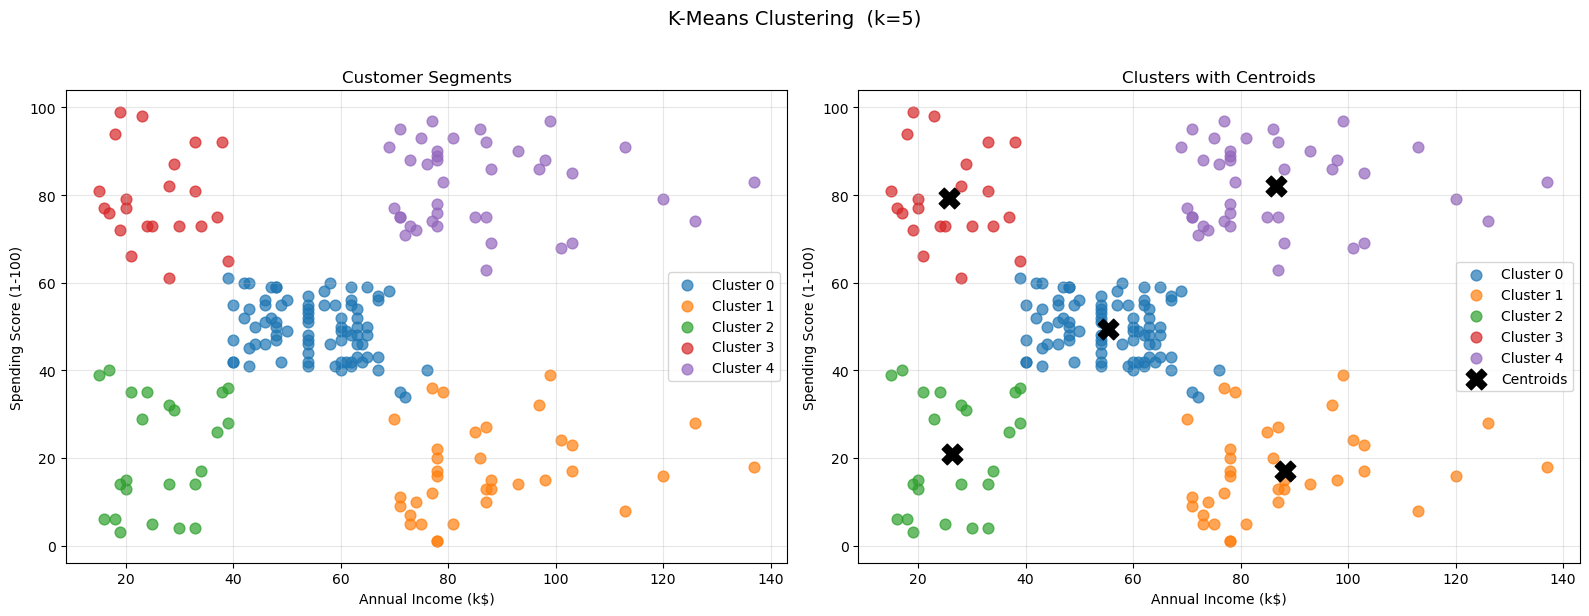

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

for ax, show_centroids in zip(axes, [False, True]):
    for cluster in range(OPTIMAL_K):
        mask = y_kmeans == cluster
        ax.scatter(
            X[mask, 0], X[mask, 1],
            s=60, alpha=0.7,
            color=colors[cluster],
            label=f'Cluster {cluster}'
        )
    if show_centroids:
        ax.scatter(
            kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            s=220, c='black', marker='X', zorder=5, label='Centroids'
        )
        ax.set_title('Clusters with Centroids')
    else:
        ax.set_title('Customer Segments')
    ax.set_xlabel(FEATURE_COLS[0])
    ax.set_ylabel(FEATURE_COLS[1])
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('K-Means Clustering  (k=5)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

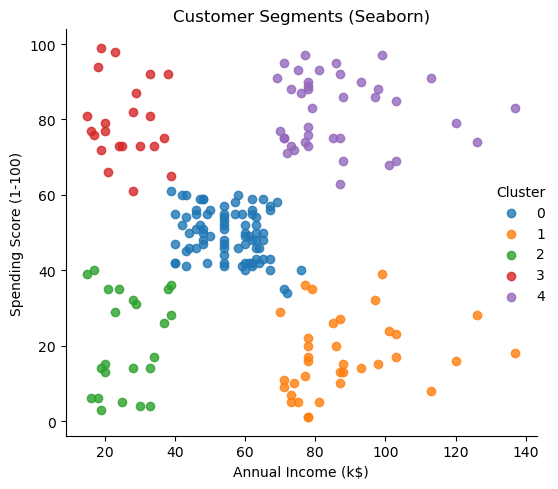

In [9]:
# Seaborn lmplot — note: legend_out must be passed via facet_kws (not directly)
facet = sns.lmplot(
    data=supervised,
    x=FEATURE_COLS[0],
    y=FEATURE_COLS[1],
    hue='Cluster',
    fit_reg=False,
    facet_kws={'legend_out': True}   # ← correct kwarg; avoids DeprecationWarning
)
facet.set_axis_labels(FEATURE_COLS[0], FEATURE_COLS[1])
plt.title('Customer Segments (Seaborn)')
plt.tight_layout()
plt.show()